In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from matplotlib.gridspec import GridSpec
from pylab import *
import glob
import pdb
import os

In [2]:
path_sta = '/nfs/scistore16/mullegrp/share/Alejo-Lok/Pollutants_Data/Consolidated_Data/'

coords = pd.read_csv(f'{path_sta}Datamap.csv')
# Calculate mean latitude and longitude for each city
city_coords = coords.groupby('City')[['lat', 'lon']].mean()

# Optional: Reset index if you want a DataFrame with "Station" as a column
city_coords = city_coords.reset_index()

In [3]:
# Path and cities
cities = ['Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']

# Dictionary to store results
city_hourly_means = {}

for city in cities:
    print(f"----------------> Processing {city}")
    pattern = os.path.join(path_sta, city, f"{city}.*.csv")
    files = sorted(glob.glob(pattern))
    
    if not files:
        print(f"No files found for {city}, skipping.")
        continue

    dfs = []

    for f in files:
        try:
            df = pd.read_csv(f, parse_dates=['Timestamp'])
            df.set_index('Timestamp', inplace=True)
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {f}: {e}")

    # Combine all stations along columns with MultiIndex
    df_combined = pd.concat(dfs, axis=1, keys=[os.path.basename(f).split('.')[1] for f in files])

    # Compute city mean for each pollutant
    df_city = pd.DataFrame(index=df_combined.index.unique().sort_values())

    available_pollutants = df_combined.columns.get_level_values(1).unique()

    for pollutant in ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (mg/m³)']:
        if pollutant in available_pollutants:
            try:
                pollutant_data = df_combined.xs(key=pollutant, axis=1, level=1)
                df_city[pollutant] = pollutant_data.mean(axis=1)
            except Exception as e:
                print(f"Error extracting {pollutant} for {city}: {e}")
        else:
            print(f"{pollutant} not available for {city}")

    df_city = df_city.sort_index().rename(columns={'index': 'Timestamp'})
    city_hourly_means[city] = df_city

    print(f"Finished {city}")

----------------> Processing Bengaluru
Finished Bengaluru
----------------> Processing Chennai
Finished Chennai
----------------> Processing Delhi
Finished Delhi
----------------> Processing Hyderabad
Finished Hyderabad
----------------> Processing Kolkata
Finished Kolkata
----------------> Processing Mumbai
Finished Mumbai


In [4]:
# CAMS data
path_cams = '/nfs/scistore16/mullegrp/acasalla/Loka_Alejo/Indian_fires/Data_pollutants/'
files_l = glob.glob(f'{path_cams}*')
files_l.remove(f'{path_cams}total_column_carbon_monoxide_India.nc')

pollu = ['CO','PM2.5','PM10']
files = {}
for i,pol in enumerate(pollu):
    files[pol] = files_l[i]

# List to collect data
all_city_data = []

for pollutant, file_path in files.items():
    ds = xr.open_dataset(file_path)

    # Auto-detect the main variable (assumes one data variable per file)
    var_name = list(ds.data_vars)[0]

    for _, row in city_coords.iterrows():
        city = row["City"]
        lat = row["lat"]
        lon = row["lon"]

        # Extract data at nearest grid point
        point_data = ds[var_name].sel(latitude=lat, longitude=lon, method="nearest")

        # Convert to DataFrame
        df = point_data.to_dataframe().reset_index()
        df["City"] = city
        df["Pollutant"] = pollutant

        all_city_data.append(df)

# Combine into a single DataFrame
final_df = pd.concat(all_city_data, ignore_index=True)
final_df.set_index("valid_time", inplace=True)

In [5]:
# Make sure valid_time is datetime and already the index
final_df.index = pd.to_datetime(final_df.index)

# List of pollutants you want to keep
pollutant_cols = ["co", "pm2p5", "pm10"]

# Group by city and create a dictionary of daily-averaged data
city_pollution_dict = {
    city: group[pollutant_cols].resample("D").mean()
    for city, group in final_df.groupby("City")
}

sta_daily = {}

for city in cities:
    df_daily = city_hourly_means[city].resample('D').mean()
    df_daily.columns = ["pm2p5", "pm10", "co"]
    df_daily = df_daily.fillna(df_daily.mean())
    sta_daily[city] = df_daily

In [6]:
def errors(M,O, umbral):
    '''This code calculate 9 metrics to evaluate model performance.
    To use it, you only need to pass two arrays, one is the model and
    the other one contain the observations. Be careful with the null values
    and the type of data! It is also important to make a good selection for the
    threshold!, if not the results would not be correct'''
    import numpy as np
    from scipy import stats
    from sklearn.metrics import mean_squared_error
    #pdb.set_trace()
    M_nan = np.nan_to_num(M,nan=np.nanmean(M))
    O_nan = np.nan_to_num(O,nan=np.nanmean(O))
    M_RAYA = np.nanmean(M)
    O_RAYA = np.nanmean(O)
    nmb = (np.nansum(M - O)/np.nansum(O)) * 100
    rmse = np.sqrt(mean_squared_error(O_nan,M_nan))
    r2 = (np.nansum((M_nan - M_RAYA) * (O_nan - O_RAYA))/np.sqrt(np.nansum((M_nan - M_RAYA)**2) * np.nansum((O_nan - O_RAYA)**2)))**2
    #fac2 = len([i for i in  M/O  if 0.5 <= i and i <=2])/ len(M)
    fac2 = np.nansum((0.5 <= M/O) & (M/O <= 2)) / len(M)
    fac2 = fac2*100
    ioa = 1 - (np.nansum((M - O)**2))/np.nansum((np.abs(M - O_RAYA) + np.abs(O - O_RAYA))**2) 
    mb = np.nanmean((M - O))
    rho = stats.spearmanr(M_nan,O_nan)
    
    na = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] > umbral])
    nb = len([i for i in np.arange(0,len(M),1) if O[i] > umbral and M[i] > umbral])
    nc = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] < umbral])
    nd = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] < umbral]) 
    
    if nb + nd > 0:  
        hit = (nb/(nb + nd))*100
    else:
        hit = 0
    if na + nb > 0:
        far = (na/(na + nb))*100
    else:
        far = 0
    if na + nb + nc + nd > 0:
        poc = ((nb + nc)/(na + nb + nc + nd))*100
    else:
        poc = 0
    return(round(nmb,2),round(rmse,2),round(rho[0],2),round(fac2,2),round(ioa,2),
           round(mb,2),round(hit,2),round(far,2),round(poc,2))

In [7]:
year = [2023]
err_mat = {}
var_mat_day = np.ones((len(cities),9))*np.nan
thr = [1.5,30,60]
const = [1e6,1e9,1e9]

for j,var in enumerate(city_pollution_dict['Delhi'].columns):
    print(var)
    var_mat_day = np.ones((len(cities),9))*np.nan
    for i,city in enumerate(cities):
        var_mat_day[i,:] = errors(city_pollution_dict[city][var].loc[f'{year[0]}-01-01':f'{year[0]}-12-31']*const[j], 
                                  sta_daily[city][var].loc[f'{year[0]}-01-01':f'{year[0]}-12-31'], thr[j])
        
    err_mat[f'{var}'] = var_mat_day

co


/tmp/ipykernel_554044/1447994794.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  na = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] > umbral])
/tmp/ipykernel_554044/1447994794.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nb = len([i for i in np.arange(0,len(M),1) if O[i] > umbral and M[i] > umbral])
/tmp/ipykernel_554044/1447994794.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nc = len([i for i 

pm2p5
pm10


/tmp/ipykernel_554044/1447994794.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nd = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] < umbral])
/tmp/ipykernel_554044/1447994794.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  na = len([i for i in np.arange(0,len(M),1) if O[i] < umbral and M[i] > umbral])
/tmp/ipykernel_554044/1447994794.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nb = len([i for i 

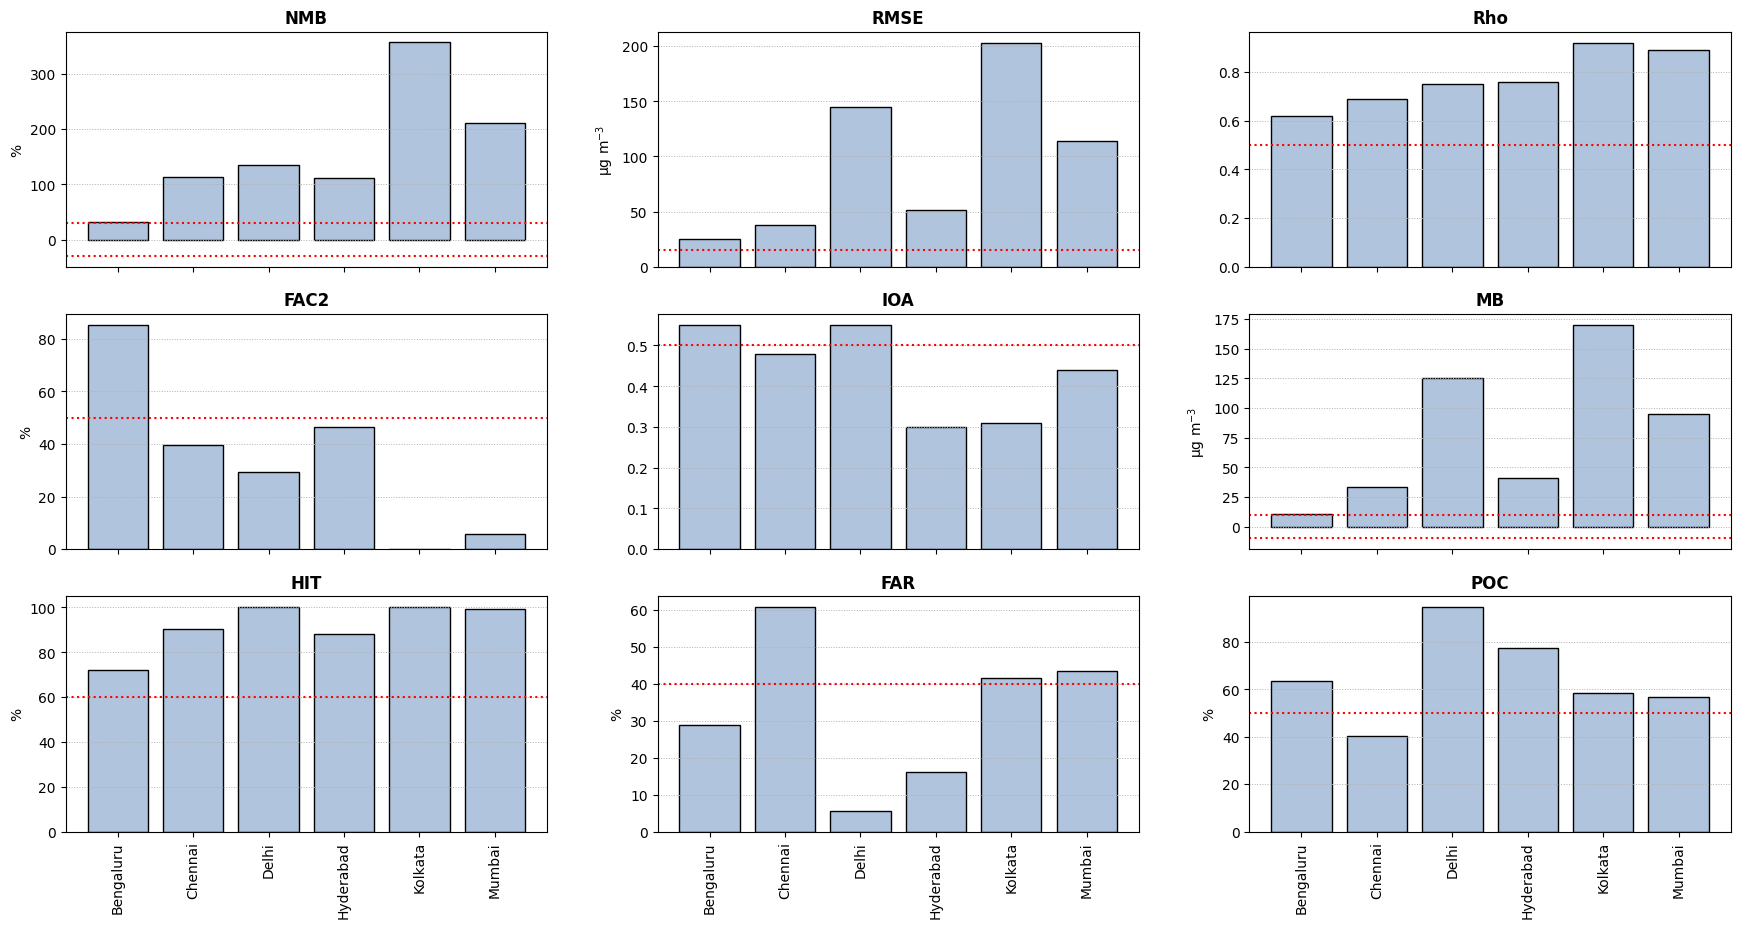

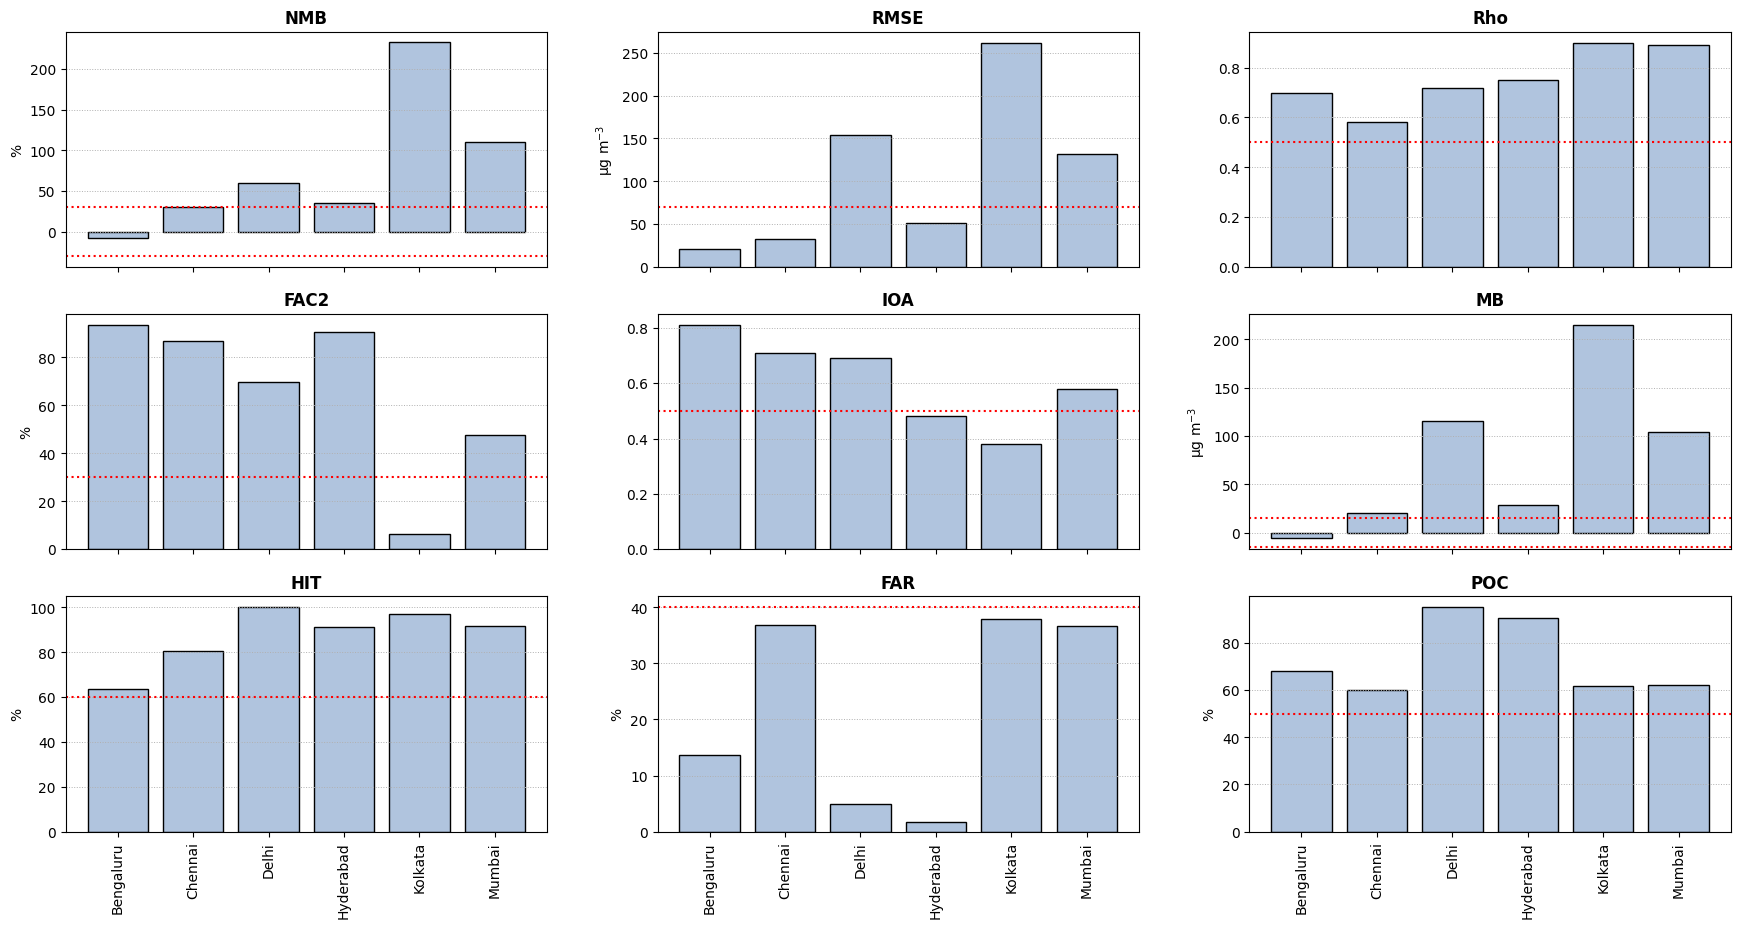

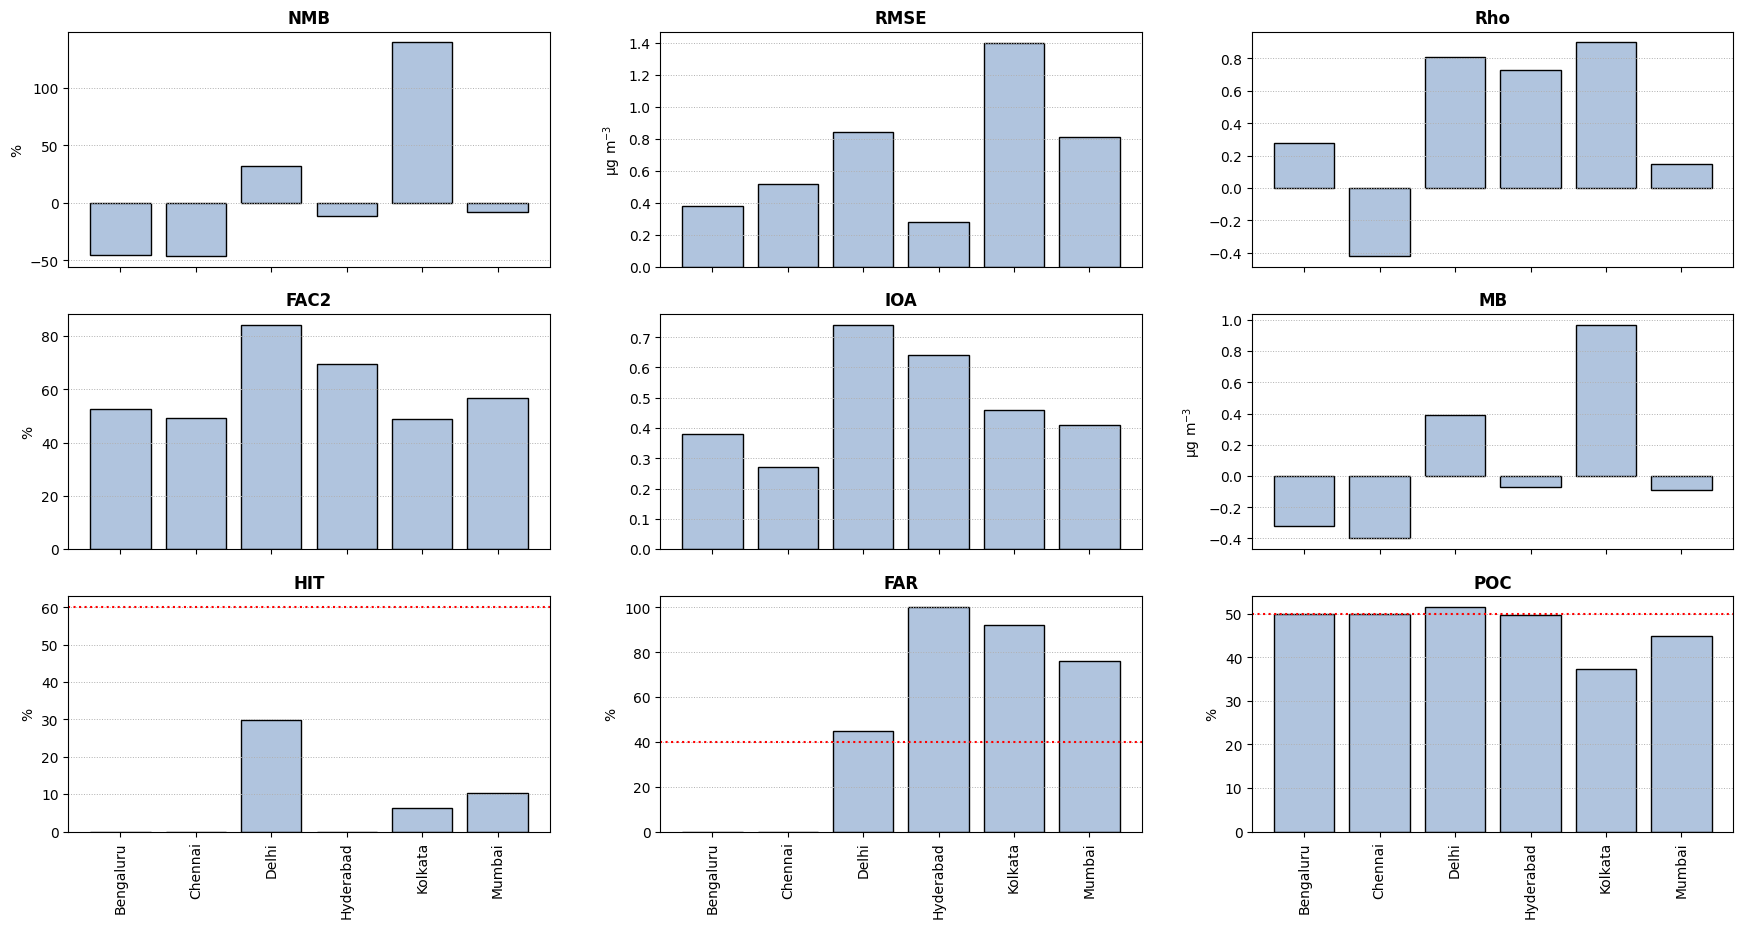

In [8]:
errores = ['NMB','RMSE','Rho','FAC2','IOA','MB','HIT','FAR','POC']
units = ['%','\u03bcg m$^{-3}$','','%','','\u03bcg m$^{-3}$','%','%','%']
pm10_bench = [30, 70, 0.5, 30, 0.5, 15, 60, 40, 50]
pm2_bench =[30, 15, 0.5, 50, 0.5, 10, 60, 40, 50]
co_bench =[None, None, None, None, None, None, 60, 40, 50]

bench = [pm2_bench, pm10_bench, co_bench]

for i,var in enumerate(['pm2p5','pm10','co']):
    fig = plt.figure(figsize=(18,10))
    gs = GridSpec(3,3, left=0.05, right=0.975, hspace=0.2, wspace=0.23, top=0.9, bottom=0.1)
    for k,error in enumerate(errores):
        ax=subplot(gs[k])
        plt.bar(cities, err_mat[var][:,k], edgecolor = 'k', color = 'lightsteelblue')
        plt.ylabel(units[k])
        plt.title(error, fontweight = 'bold')
        plt.xticks(rotation = 90)
        plt.grid(linestyle=':', linewidth=0.7, axis = 'y')
        if i == 2:
            if k < 6:
                ax.xaxis.set_major_formatter(NullFormatter())
            else:
                plt.axhline(bench[i][k], color = 'red', linestyle = ':')
        else:
            plt.axhline(bench[i][k], color = 'red', linestyle = ':')
            if k == 0 or k == 5:
                plt.axhline(bench[i][k]*(-1), color = 'red', linestyle = ':')
            if k < 6:
                ax.xaxis.set_major_formatter(NullFormatter())
    plt.savefig(f'../Figures/Validation_CAMS_{var}.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

## Baseline Calculation

In [9]:
# Parameters
M_values = [1, 2, 3, 4]  # Different M values to check
years = list(range(2017, 2024))  # From 2013 to 2023

# List of cities (you must have this list somewhere)
cities = list(city_pollution_dict.keys())

# Initialize the big dictionary to store results
baseline_results = {}

# Start looping
for i,var in enumerate(city_pollution_dict['Delhi'].keys()):
    for city in cities:
        print(f"Processing {city} - {var}")
        
        # Access series
        series = city_pollution_dict[city][var]
        
        # Ensure it's a pandas Series
        series = pd.Series(series)
        
        # Ensure datetime index
        if not isinstance(series.index, pd.DatetimeIndex):
            series.index = pd.to_datetime(series.index)
        
        # Multiply by a constant 
        series = series * const[i]
        
        # Initialize storage if not exist
        if city not in baseline_results:
            baseline_results[city] = {}
        if var not in baseline_results[city]:
            baseline_results[city][var] = {}
        
        # Now loop over years
        for year in years:
            try:
                series_year = series.loc[str(year)]
            except KeyError:
                print(f"No data for {city} in {year} — skipping...")
                continue

            if series_year.empty:
                print(f"No data for {city} in {year} — skipping...")
                continue
            
            # Weekly average (Sunday-Saturday)
            weekly_avg = series_year.resample('W-SAT').mean()
            
            # Sort weekly averages (smallest to largest)
            sorted_weekly = weekly_avg.sort_values()
            
            # Calculate baselines for different M
            year_baselines = {}
            for M in M_values:
                if len(sorted_weekly) < M:
                    print(f"Not enough weeks ({len(sorted_weekly)}) for M={M} — skipping...")
                    continue
                lowest_M_weeks = sorted_weekly.iloc[:M]
                baseline_mean = lowest_M_weeks.mean()
                year_baselines[M] = baseline_mean
            
            # Save for this year
            baseline_results[city][var][year] = year_baselines

print("\n Baseline dictionary per year constructed successfully!")


Processing Bengaluru - co
Processing Chennai - co
Processing Delhi - co
Processing Hyderabad - co
Processing Kolkata - co
Processing Mumbai - co
Processing Bengaluru - pm2p5
Processing Chennai - pm2p5
Processing Delhi - pm2p5
Processing Hyderabad - pm2p5
Processing Kolkata - pm2p5
Processing Mumbai - pm2p5
Processing Bengaluru - pm10
Processing Chennai - pm10
Processing Delhi - pm10
Processing Hyderabad - pm10
Processing Kolkata - pm10
Processing Mumbai - pm10

 Baseline dictionary per year constructed successfully!


Plotting variable: co


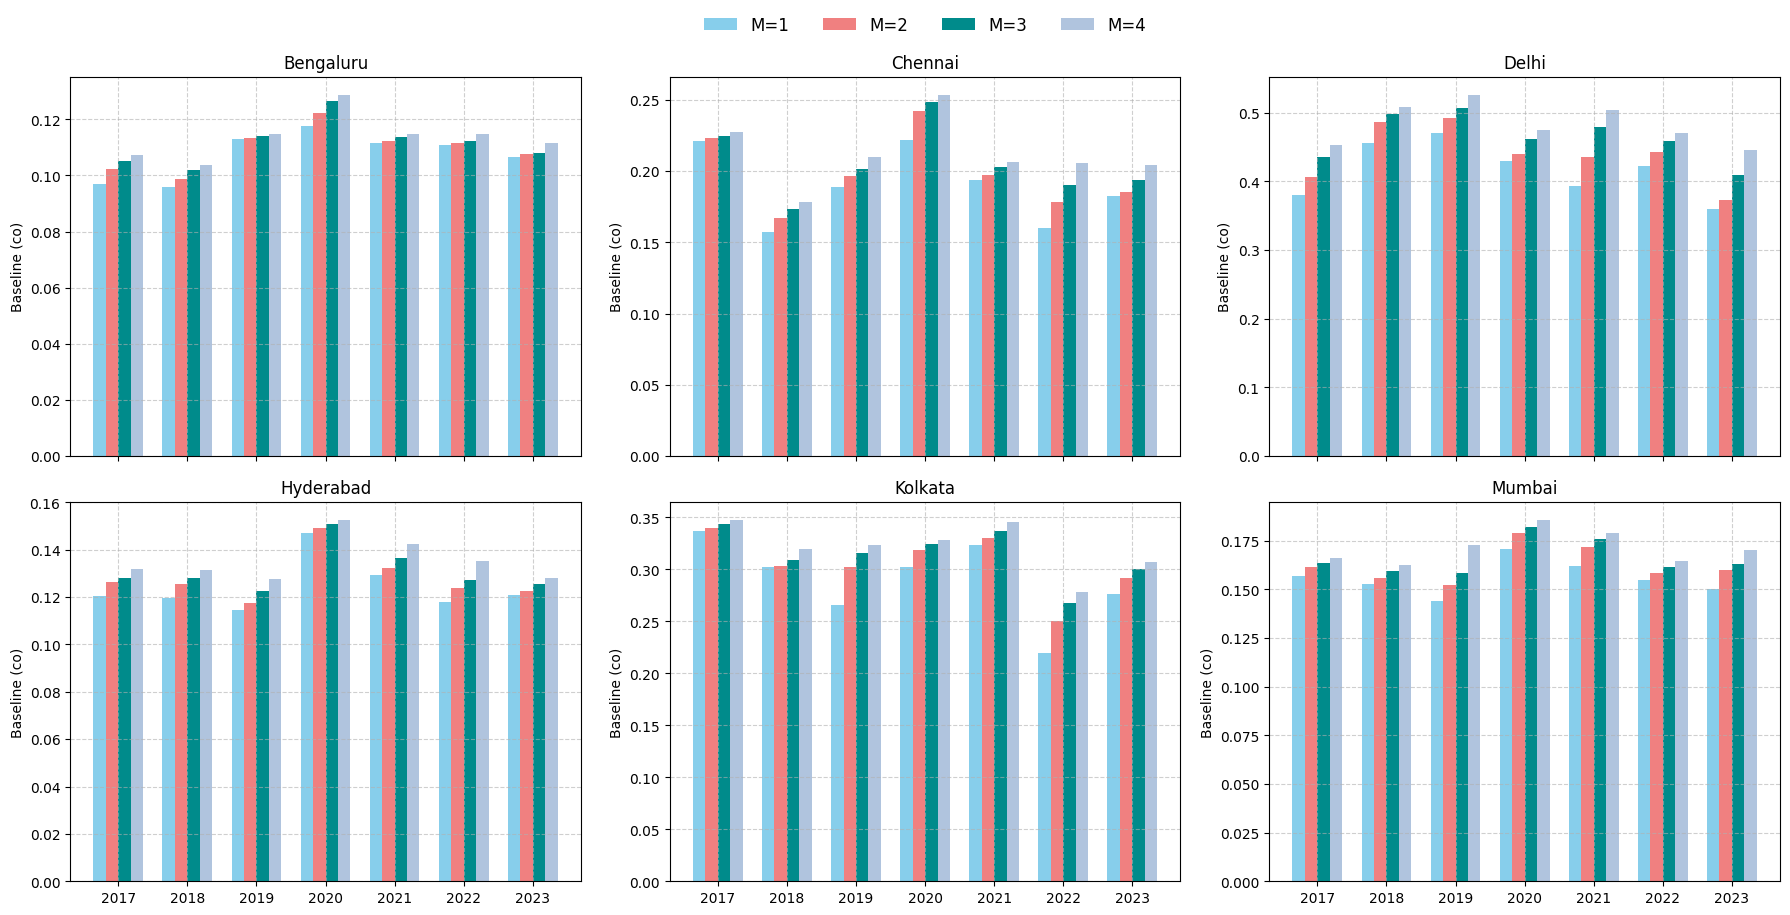

Plotting variable: pm2p5


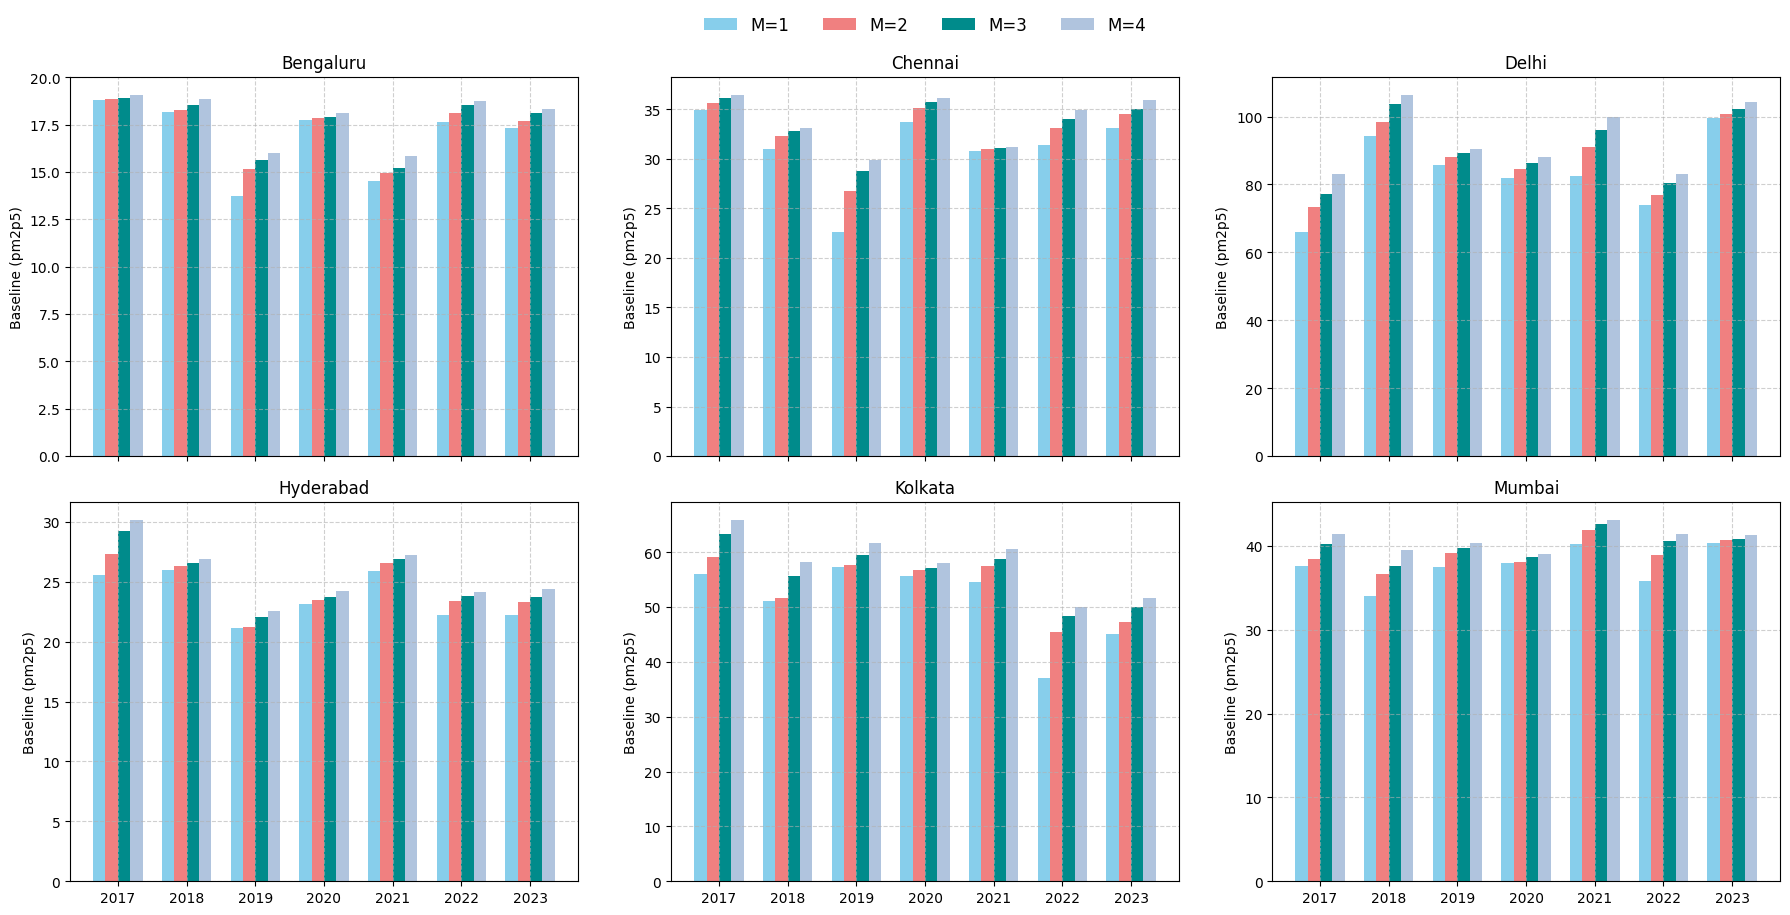

Plotting variable: pm10


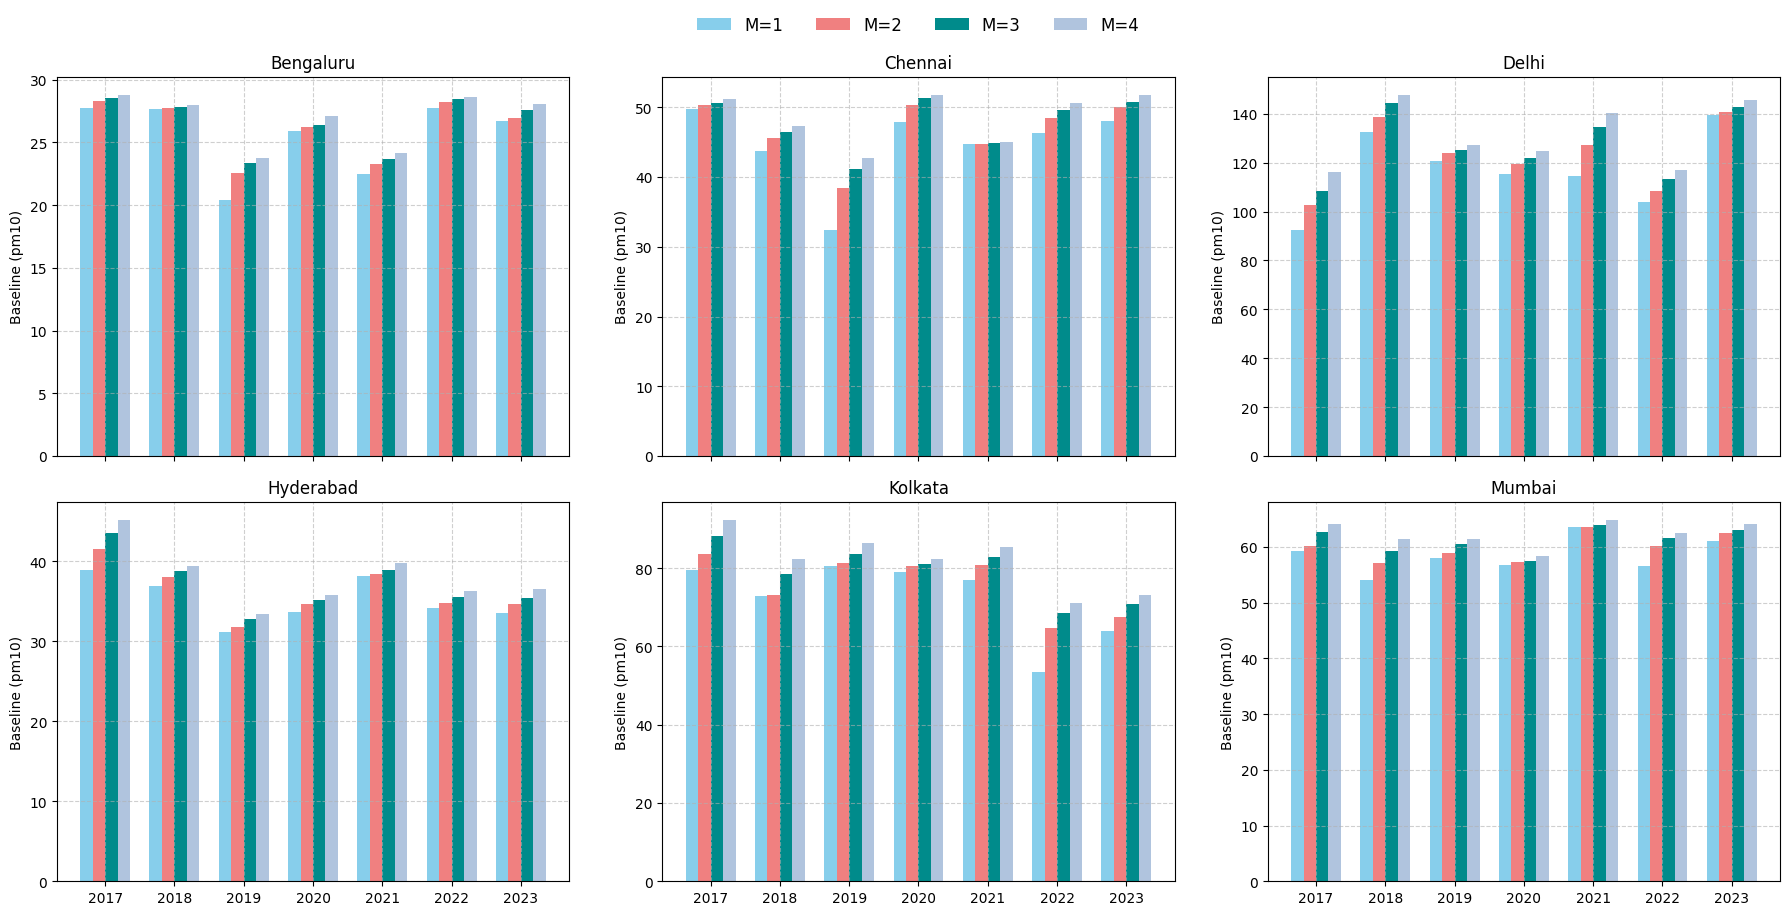

In [10]:
# Parameters
M_values = [1, 2, 3, 4]
years = list(range(2013, 2024))
cities = list(baseline_results.keys())
variables = list(baseline_results[cities[0]].keys())  # Assuming all cities have same variables

# Colors for the bars
colors = ['skyblue', 'lightcoral', 'darkcyan', 'lightsteelblue']

# Plotting
for var in variables:
    print(f"Plotting variable: {var}")

    # 3 columns and 2 rows (change here)
    ncols = 3
    nrows = 2
    fig, axs = plt.subplots(nrows, ncols, figsize=(18, 10), sharex=True)

    axs = axs.flatten()  # Flatten axs array for easy indexing
    
    for idx, city in enumerate(cities):
        if idx >= nrows * ncols:
            break  # Only plot up to 6 cities (if more, skip or you can create new figure if needed)

        ax = axs[idx]
        
        width = 0.18  # Width of each bar
        offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]  # 4 bars per year
        
        for m_idx, M in enumerate(M_values):
            values = []
            for year in years:
                try:
                    baseline = baseline_results[city][var][year][M]
                except KeyError:
                    baseline = np.nan
                values.append(baseline)

            x_pos = np.array(years) + offsets[m_idx]
            ax.bar(x_pos, values, width=width, label=f'M={M}', color=colors[m_idx])

        ax.set_title(f"{city}", fontsize=12)
        ax.set_ylabel(f"Baseline ({var})", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        if idx == 1:
            ax.legend(frameon = False, loc="upper center", fontsize=12, ncol = 4, bbox_to_anchor = (0.5, 1.2))
    
    # Hide unused subplots if any
    for j in range(len(cities), nrows * ncols):
        fig.delaxes(axs[j])

    # Common x-label
    #fig.supxlabel("Year", fontsize=14)
    #fig.supylabel("Baseline", fontsize=14)
    #fig.suptitle(f"Baseline PM2.5 per Year - Variable: {var}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'../Figures/Baseline_{var}.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

In [11]:
# Output directory for CSVs
output_dir = "/nfs/scistore16/mullegrp/acasalla/Loka_Alejo/Indian_fires"

# Option 1: One CSV per city
for city in baseline_results.keys():
    data = []

    for var in baseline_results[city].keys():
        for year in baseline_results[city][var].keys():
            try:
                m2_value = baseline_results[city][var][year][2]  # Only M=2
            except KeyError:
                m2_value = None  # Handle missing data

            # Collect rows: variable, year, M2 baseline value
            data.append({
                "variable": var,
                "year": year,
                "baseline_M2": m2_value
            })
    
    # Convert collected data to a DataFrame
    df_city = pd.DataFrame(data)
    df_city = df_city.sort_values(by=["variable", "year"])

    # Save DataFrame to CSV
    output_path = os.path.join(output_dir, f"{city}_baseline_M2.csv")
    df_city.to_csv(output_path, index=False)

print("\n All city M=2 baseline CSVs saved!")




 All city M=2 baseline CSVs saved!
